In [ ]:
import numpy as np                     # Numerical programming package
import matplotlib.pyplot as plt        # Plotting library
import scipy as sci                    # Scientific computing library
from scipy import constants as scicost # Physical and Mathematical constants
from tqdm import tqdm                  # A progress bar (interesting note: tqdm means "progress" in Arabic (taqadum, تقدّم))
import numba as nb                     # A Just-In-Time Compiler for Numerical Functions in Python

# Units normalization
As in many Particle-In-Cell codes we adopt the following normalization conventions:

- Angular frequencies are normalized w.r.t an arbitrary $\omega_R$
- Times are normalized w.r.t. $T_R = 1/\omega_R$
- Lengths are normalized w.r.t. $L_R = c / \omega_R$
- Electric fields are normalized w.r.t. $E_R = {{m_e c \omega_R} \over {e}}$
- Magnetic fields are normalized w.r.t. $B_R = {{m_e \omega_R} \over {e}}$
- Number densities are normalized w.r.t. $N_R = {{\epsilon_0 m_e \omega_R^2} \over {e_0^2}}$
- Current densities are normalized w.r.t. $j_R = c e_0 N_R$
- Electric charge is normalized w.r.t. $e_r = e_0$
- Mass is normalized w.r.t. $m_R = m_e$

Note that with this choice the speed of light is equal to 1

___

# Relativistic Particle pusher

##  Exercise 0: integrate the trajectory of a particle in a magnetic field with a naïve solver [SOLVED]

**Note: this exercise is a slightly modified version of the exercise that we solved during the first session (the initial velocity of the particle is now relativistic)**

The relativistic equations of motion of a charged particle in a constant electromagnetic field read as follows:
- Momentum equation
$\dfrac{d\mathbf{p}}{dt} = q \left(\textbf{E}+\textbf{v} \times \textbf{B}\right)$
- Position equation
$\dfrac{d\mathbf{x}}{dt} = \mathbf{v}$

where $q$ is the particle's charge, $m$ is its mass,  $\mathbf{p} = \gamma m \mathbf{v}$, and $\gamma = \sqrt{1 + (\mathbf{p}/mc)^2}$

If we try to naively apply the LeapFrog method to these equations we get something like that:

- Momentum equation
$\textbf{p}^{n+1/2}=\textbf{p}^{n-1/2}+q \left(\textbf{E}^{n}+\textbf{v}^{n-1/2}\times \textbf{B}^{n}\right) dt$
- Position equation
$\textbf{x}^{n+1}=\textbf{x}^{n}+ dt \textbf{v}^{n+1/2}$

Complete the python function 'push_particle_naive' (suggestion: you can use the `np.cross` function). Then, test the particle pusher by running `test_push_particle_naive`. The test simulates the trajectory of an electron with an initial velocity $\textbf{v}_0 = 2 \cdot 10^{8}$ m/s ($\gamma \approx 1.34$) perpendicular to a magnetic field $\textbf{B}_0 = 1 $ T. Theoretically, the orbit should be a circle with radius $R_{L}=m_ev_0/eB_0$. What is wrong with this pusher?

In [ ]:
###########################
# DO NOT MODIFY THIS CELL #
###########################
def push_particle_naive(pos,p,E,B,dt,q,m):
    '''
    Parameters
    ----------

    pos: position vector x^n
    p  : momentum vector p^(n-1/2)
    E  : E^n vector
    B  : B^n vector
    dt : timestep
    q  : charge
    m  : mass

    Output
    ----------

    This function returns X^(n+1) and p^(n+1/2)
    '''

    def v_from_p (p):
        u = p/m
        return u/ np.sqrt( 1.0 + np.dot(u,u))

    #######SOLVED############
    new_p   = p + q*(E + np.cross(v_from_p(p), B))*dt
    new_pos = pos + v_from_p(new_p)*dt
    ###########################

    return new_pos,new_p

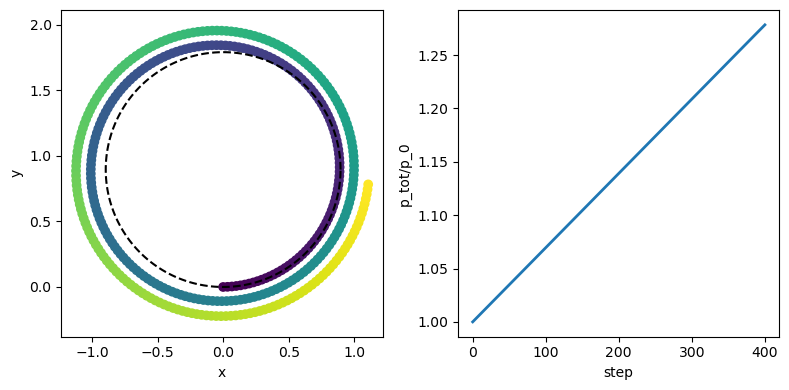

In [ ]:
###########################
# DO NOT MODIFY THIS CELL #
###########################
def do_simulation_naive (q, m, E0, B0, V0, dt, Ns):
    ### We want to record the full trajectory of the particle
    pos = np.zeros((3,Ns+1))
    p = np.zeros((3,Ns+1))

    p0 = m*V0/np.sqrt(1-np.sum(V0**2))
    p[:,0] = p0

    for i in range(Ns):
        pos[:,i+1], p[:,i+1] = push_particle_naive(pos[:,i],p[:,i],E0,B0,dt,q,m)

    return pos, p


def test_push_particle_naive():
    ### Initial conditions
    B0_SI = 1
    V0_SI = 2e8

    ### Initial conditions in normalized units
    Q_r = scicost.e
    M_r = scicost.m_e
    V_r = scicost.c

    omega_r = scicost.e*B0_SI/scicost.m_e
    E_r = scicost.m_e * omega_r * scicost.c / scicost.e
    B_r = scicost.m_e * omega_r / scicost.e

    m = 1
    q = -1
    E0 = np.array([0,0,0])
    B0 = np.array([0,0,B0_SI/B_r])
    V0 = np.array([V0_SI/V_r,0,0])

    ### Simulation parameters
    final_time = 20
    dt = 0.05
    Ns = int(final_time / dt)

    ### Run simulation and plot the trajectory

    pos_naive, p_naive = do_simulation_naive (q, m, E0, B0, V0, dt, Ns)

    fig, ax = plt.subplots(1,2,figsize=(8,4))
    ax[0].set_xlabel("x")
    ax[0].set_ylabel("y")

    theta = np.linspace(0,np.pi*2.0,200)
    Rl = m*V0[0]/np.abs(q)/B0[2]/np.sqrt(1 - V0[0]**2)
    xl = np.cos(theta)*Rl
    yl = np.sin(theta)*Rl + Rl
    ax[0].plot(xl,yl,'k--')

    ax[0].plot(pos_naive[0,:],pos_naive[1,:],zorder=-1)
    ax[0].scatter(pos_naive[0,:],pos_naive[1,:],c=range(Ns+1))

    ax[0].axis('equal')

    ax[1].set_xlabel("step")
    ax[1].set_ylabel("p_tot/p_0")

    ax[1].plot(range(Ns+1), np.sqrt(p_naive[0,:]**2 + p_naive[1,:]**2 + p_naive[2,:]**2)/p_naive[0,0],linewidth=2)

    plt.tight_layout()

    plt.show()

test_push_particle_naive()

### The Boris pusher(1970)
In order to fix the time centering issue with our particle pusher, we could write:

$\textbf{u}^{n+1/2}=\textbf{u}^{n-1/2}+\frac{q}{m}\left(\textbf{E}^{n}+\dfrac{\textbf{u}^{*,n}}{\gamma^{*,n}}\times \textbf{B}^{n}\right) dt $

where $\textbf{u}^{*,n}$ is the average of $\textbf{u}^{n+1/2}$ and $\textbf{u}^{n-1/2}$ (with $\gamma^{*,n} = (\gamma^{n+1/2} +\gamma^{n-1/2} )/2$):

$\textbf{u}^{n+1/2}=\textbf{u}^{n-1/2}+\frac{q}{m}dt\left(\textbf{E}^{n}+\frac{\textbf{u}^{n-1/2}+\textbf{u}^{n+1/2}}{2\gamma^{*,n}}\times \textbf{B}^{n}\right)$ (1)

This would lead to an implicit solver. Implicit solvers can be used, but they are expensive from the computational point of view (we typically need to use an iterative method).


Boris found an ingenious explicit solver, by remarking that we can eliminate the electric field in the velocity equation by defining:

$\textbf{u}^{-}=\textbf{u}^{n-1/2}+\frac{q\textbf{E}}{m}\frac{dt}{2}$ (2)

and

$\textbf{u}^{n+1/2}=\textbf{u}^{+}+\frac{q\textbf{E}}{m}\frac{dt}{2}$ (3)

When (2) and (3) are plugged into (1), we get a pure rotation in the magnetic field (assuming that we can approximate $\gamma^{*,n}$ with $\gamma(\textbf{u}^{-})$) :

$\frac{\textbf{u}^{+}-\textbf{u}^{-}}{dt}= \frac{q}{2 \gamma m}\left(\textbf{u}^{+}+\textbf{u}^{-}\right)\times \textbf{B}$ (4)

By means of simple geometry considerations (not detailed here), Boris showed that we can obtain $\textbf{u}^{+}$ from $\textbf{u}^{-}$ by rewriting (4) in 2 stages:

$\textbf{u}^{\prime}=\textbf{u}^{-}+\textbf{u}^{-}\times\textbf{t}$ with $\textbf{t}=\frac{q\textbf{B}}{\gamma m}\frac{dt}{2}$  and $\gamma = \sqrt{1 + \textbf{u}^{-} \cdot  \textbf{u}^{-} }$ (5)

and

$\textbf{u}^{+}=\textbf{u}^{-}+\textbf{u}^{\prime}\times\textbf{s}$ (6)

where:

$\textbf{s} = \frac{2\textbf{t}}{1+t^2}$

To summarize, the Boris pusher consists of three stages:

1. Half-"push" (dt/2) of $\textbf{u}^{n-1/2}$ with $\textbf{E}$ to obtain $\textbf{u}^{-}$ (eq. (2))
2. Complete "push" of $\textbf{u}^{-}$ (dt) to obtain $\textbf{u}^{+}$ in two stages (eq. (5) and eq. (6))
3. Half-"push" (dt/2) of $\textbf{u}^{+}$ with $\textbf{E}$ to obtain $\textbf{u}^{n+1/2}$ (eq. (3))


## Exercise 1: The Boris pusher(1970)

Complete the python function `push_particle_momentum_boris` to implement the "Boris" pusher to advance the particles' momentum. Then, test the particle pusher by running `test_push_particle_boris`.  Note that `push_particle_momentum_boris` is responsible for updating only the particles' momentum. Updating the particles' position in done by `push_particle_position` (separating the update of positions and momenta is important for the full PIC loop).

Use the numpy functions `np.cross` and `np.dot` to compute, respectively, vector products and scalar products between vectors.

Suggestion: if the error messages are not clear, you can comment out `@nb.jit(nopython=True, fastmath = True)` However, remember to re-enable it, otherwise the PIC simulation will be slow!

In [ ]:
@nb.jit(nopython=True, fastmath = True)
def push_particle_position (pos, u, dt):
    '''
    Parameters
    ----------

    pos: position vector x^n
    p  : momentum vector p^(n-1/2)
    dt : timestep

    Output
    ----------

    This function returns x^(n+1)

    '''
    v = u / np.sqrt(1 + np.dot(u,u) )
    new_pos = pos + v*dt

    return new_pos

@nb.jit(nopython=True, fastmath = True)
def push_particle_momentum_boris(u,E,B,dt,q,m):
    '''
    Parameters
    ----------
    p  : momentum vector p^(n-1/2)
    E  : E^n vector, computed at the particle's position
    B  : B^n vector, computed at the particle's position
    dt : timestep
    q  : charge
    m  : mass

    Output
    ----------

    This function returns p^(n+1/2)
    '''

    cc = (q/m)*(dt/2)

    ### ADD YOUR CODE HERE ####
    # u_minus  = ...
    # [...]
    new_u = u
    ### ADD YOUR CODE HERE ####

    #######SOLUTION############
    u_minus  = u + E*cc
    gg = np.sqrt(1 + np.dot(u_minus,u_minus) )
    tee = cc * B/gg
    u_primed = u_minus + np.cross(u_minus, tee)
    ss = 2*tee/(1+np.dot(tee,tee))
    u_plus = u_minus + np.cross(u_primed, ss)
    new_u = u_plus + E*cc
    ###########################

    return new_u

/var/folders/lt/f_1jrwr52xj0xswyl2kt9gz40000gn/T/ipykernel_32390/3873993509.py:17: NumbaPerformanceWarning: np.dot() is faster on contiguous arrays, called on (Array(float64, 1, 'A', False, aligned=True), Array(float64, 1, 'A', False, aligned=True))
  v = u / np.sqrt(1 + np.dot(u,u) )


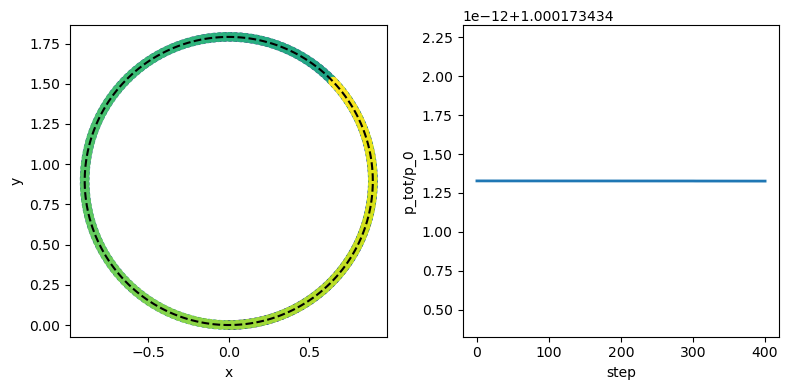

In [ ]:
###########################
# DO NOT MODIFY THIS CELL #
###########################
def do_simulation_boris (q, m, E0, B0, V0, dt, Ns):
    ### We want to record the full trajectory of the particle
    pos = np.zeros((3,Ns+1))
    u = np.zeros((3,Ns+1))

    u0 = V0/np.sqrt(1-np.sum(V0**2))
    # half step forward for momentum
    u[:,0] = push_particle_momentum_boris(u0,E0,B0,+.5*dt,q,m)

    for i in range(Ns):
        pos[:,i+1] = push_particle_position(pos[:,i],u[:,i],dt)
        u[:,i+1] = push_particle_momentum_boris(u[:,i],E0,B0,dt,q,m)

    p = u*m
    return pos, p


def test_push_particle_boris():
    ### Initial conditions
    B0_SI = 1
    V0_SI = 2e8

    ### Initial conditions in normalized units
    Q_r = scicost.e
    M_r = scicost.m_e
    V_r = scicost.c

    omega_r = scicost.e*B0_SI/scicost.m_e
    E_r = scicost.m_e * omega_r * scicost.c / scicost.e
    B_r = scicost.m_e * omega_r / scicost.e

    m = 1
    q = -1
    E0 = np.array([0,0,0])
    B0 = np.array([0,0,B0_SI/B_r])
    V0 = np.array([V0_SI/V_r,0,0])

    ### Simulation parameters
    final_time = 20
    dt = 0.05
    Ns = int(final_time / dt)

    ### Run simulation and plot the trajectory
    pos_boris, p_boris = do_simulation_boris (q, m, E0, B0, V0, dt, Ns)

    fig, ax = plt.subplots(1,2,figsize=(8,4))
    ax[0].set_xlabel("x")
    ax[0].set_ylabel("y")

    theta = np.linspace(0,np.pi*2.0,200)
    Rl = m*V0[0]/np.abs(q)/B0[2]/np.sqrt(1 - V0[0]**2)
    xl = np.cos(theta)*Rl
    yl = np.sin(theta)*Rl + Rl
    ax[0].plot(xl,yl,'k--')

    ax[0].plot(pos_boris[0,:],pos_boris[1,:],zorder=-1)
    ax[0].scatter(pos_boris[0,:],pos_boris[1,:],c=range(Ns+1))

    ax[0].axis('equal')

    ax[1].set_xlabel("step")
    ax[1].set_ylabel("p_tot/p_0")

    ax[1].plot(range(Ns+1), np.sqrt(p_boris[0,:]**2 + p_boris[1,:]**2 + p_boris[2,:]**2)/p_boris[0,0],linewidth=2)

    plt.tight_layout()

    plt.show()

test_push_particle_boris()

# Interpolation from/to the grid

## Exercise 2: implement shapefactor calculation for a triangular shapefunction

Complete the code in `compute_shape_factors_triangular` to implement a function that computes the three shape factors for a triangular distribution function, as a function of the displacement `ds` from the central node (normalized with respect to the grid resolution dx). Note that `ds <= 0.5`. Then, run `test_compute_shape_factors_triangular`.

In [ ]:
@nb.jit(nopython=True, fastmath = True)
def compute_shape_factors_triangular(ds):
    '''
    This function computes the shapefactors for a triangular shapefunction as a function of
    the displacement with respect to the central node (normalized with respect to the grid resolution dx)

    Parameters
    ----------

    ds: displacement with respect to the central node (normalized with respect to the grid resolution dx)

    Output
    ----------

    The three shape factors s_left, s_center, and s_right

    '''

    ### ADD YOUR CODE HERE ####
    s_left = 0.0*ds
    s_right = 0.0*ds
    s_center = 0.0*ds
    ######################

    ### SOLUTION ####
    s_left = 0.5*(ds-0.5)**2
    s_center = 0.75 - ds**2
    s_right = 0.5*(ds+0.5)**2
    ######################

    return s_left, s_center, s_right

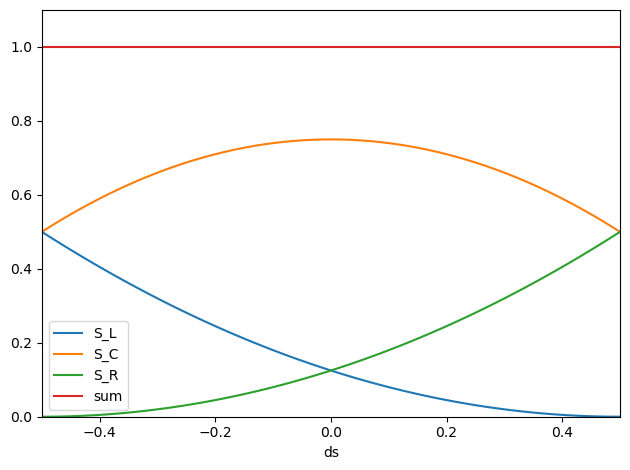

In [ ]:
###########################
# DO NOT MODIFY THIS CELL #
###########################

def test_compute_shape_factors_triangular():
    ds = np.linspace(-0.5,0.5,100)

    s_left, s_center, s_right = compute_shape_factors_triangular(ds)

    plt.plot(ds, s_left, label="S_L")
    plt.plot(ds, s_center, label="S_C")
    plt.plot(ds, s_right, label="S_R")

    plt.plot(ds, s_left + s_center + s_right, label="sum")

    plt.xlim(-0.5,0.5)
    plt.ylim(0,1.1)

    plt.xlabel("ds")

    plt.tight_layout()
    plt.legend()

test_compute_shape_factors_triangular()

# A full 1D3V PIC code

The code below implements a Relativistic 1D3V PIC code by re-using the code above and the Maxwell solver that we developed in the last lectures.


In [ ]:
###########################
# DO NOT MODIFY THIS CELL #
###########################

class EM1D:
    '''
    This class stores the EM field components and provides methods to initialize and update the fields
    '''

    def __init__(self, N_cells, x0, x1):
        '''
        This function initializes the simulation box and allocates field data.
        N_cells is the number of physical cells. We are introducing additional "guard cells"
        on the left and on the right. For this application we only need one guard cell on the left
        for the magnetic field and one on the right for the electric field,
        in order to deal with boundary conditions cleanly. However, for future applications of this solver we
        add two guard cells on each side.
        x0 is the coordinate of the first grid point of the EM field. x1 is the coordinate of the
        first guard cell on the right. The following "figure" should clarify these choices:

        [0]  [x]  [0]  [x]   0    X    0    X    0    X    0    X   [0]  [x]  [0]  [x]
                             ^                                       ^
                            x_0                                     x_1

        0 : integer points
        X : half-integer points
        [X] or [0]: guard cells
        '''
        ng = 2 ## guard cells on each side
        self.ng = ng
        self.N = N_cells + 2*ng
        self.x0 = x0
        self.x1 = x1
        self.dx = (x1-x0)/N_cells
        self.xx = np.linspace(
            self.x0-ng*self.dx,
            self.x1+(ng-1)*self.dx,
            self.N) #integer coords (including guard cells)
        self.xxh = self.xx + self.dx*0.5 #half-integer coordinates (including guard cells)

        self.Ex = np.zeros(self.N)
        self.Ey = np.zeros(self.N)
        self.Ez = np.zeros(self.N)
        self.Bx = np.zeros(self.N)
        self.By = np.zeros(self.N)
        self.Bz = np.zeros(self.N)


    def init_Ex_with_density(self,rho):
        '''
        This function initializes E_x using the initial density.
        The user must ensure that sum(rho) ~ 0 (i.e., global neutrality)
        '''
        ng = self.ng
        self.Ex[ng:-ng] = np.cumsum(rho*self.dx)


    def get_coords_without_guard_cells(self):
        ng = self.ng
        return (
            self.xx[ng:-ng],
            self.xxh[ng:-ng])


    def get_fields_without_guard_cells(self):
        ng = self.ng
        return (self.Ex[ng:-ng],
                self.Ey[ng:-ng],
                self.Ez[ng:-ng],
                self.Bx[ng:-ng],
                self.By[ng:-ng],
                self.Bz[ng:-ng])

    def advance_E(self, dt, jx, jy, jz):
        '''
        This function evolves the magnetic field by dt, using the current components jx, jy, jz
        '''
        ng = self.ng
        self.Ey[ng:-ng] = self.Ey[ng:-ng] - (dt/self.dx)*np.diff(self.Bz[(ng-1):-ng])
        self.Ez[ng:-ng] = self.Ez[ng:-ng] + (dt/self.dx)*np.diff(self.By[(ng-1):-ng])

        if jx is not None :
            self.Ex[ng:-ng] = self.Ex[ng:-ng] - jx*dt
        if jy is not None :
            self.Ey[ng:-ng] = self.Ey[ng:-ng] - jy*dt
        if jz is not None :
            self.Ez[ng:-ng] = self.Ez[ng:-ng] - jz*dt

    def advance_B(self, dt):
        '''
        This function evolves the magnetic field by dt
        '''
        ng = self.ng

        # no need to evolve Bx

        self.By[ng:-ng] = self.By[ng:-ng] + (dt/self.dx)*np.diff(self.Ez[ng:-(ng-1)])
        self.Bz[ng:-ng] = self.Bz[ng:-ng] - (dt/self.dx)*np.diff(self.Ey[ng:-(ng-1)])

    def set_transverse_fields(self, Eyf, Ezf, Byf, Bzf):
        '''
        This function sets the transverse fields given some functors
        '''
        ng = self.ng

        if Eyf is not None :
            self.Ey[ng:-ng] = Eyf(self.xx[ng:-ng])
        if Ezf is not None :
            self.Ez[ng:-ng] = Ezf(self.xx[ng:-ng])
        if Byf is not None :
            self.By[ng:-ng] = Byf(self.xxh[ng:-ng])
        if Bzf is not None :
            self.Bz[ng:-ng] = Bzf(self.xxh[ng:-ng])

    def apply_E_boundary(self, bondary_type):
        '''
        This function applies boundary conditions to the E field
        '''
        if (bondary_type == "reflective"):
            pass # do nothing
        elif (bondary_type == "periodic"):

            ng = self.ng

            self.Ey[-ng:] = self.Ey[ng:2*ng]
            self.Ez[-ng:] = self.Ez[ng:2*ng]
            self.Ey[0:ng] = self.Ey[-2*ng:-ng]
            self.Ez[0:ng] = self.Ez[-2*ng:-ng]
            pass
        else:
            raise Exception("Sorry, no boundary condition with this name")


    def apply_B_boundary(self, bondary_type):
        '''
        This function applies boundary conditions to the B field
        '''
        if (bondary_type == "reflective"):
            pass # do nothing
        elif (bondary_type == "periodic"):

            ng = self.ng

            self.By[-ng:] = self.By[ng:2*ng]
            self.Bz[-ng:] = self.Bz[ng:2*ng]
            self.By[0:ng] = self.By[-2*ng:-ng]
            self.Bz[0:ng] = self.Bz[-2*ng:-ng]
            pass
        else:
            raise Exception("Sorry, no boundary condition with this name")

class species:

    def __init__ (self, charge, mass):
        self.q = charge
        self.m = mass

        self.npart = 0
        self.x = np.array(0)
        self.ux = np.array(0)
        self.uy = np.array(0)
        self.uz = np.array(0)
        self.w = np.array(0)

    def init_plasma (self, grid, number_density_functor, particles_per_cell, dx):
        number_density = number_density_functor(grid)
        where_nonzero = (number_density > 0)
        self.n_part = np.count_nonzero(number_density) * particles_per_cell

        self.x = np.zeros(self.n_part)
        self.ux = np.zeros(self.n_part)
        self.uy = np.zeros(self.n_part)
        self.uz = np.zeros(self.n_part)
        self.w = np.zeros(self.n_part)

        grid_where_nonzero = grid[where_nonzero]
        den_where_nonzero  = number_density[where_nonzero]

        for i in range(len(grid_where_nonzero)):
            xc  = grid_where_nonzero[i]
            den = den_where_nonzero[i]
            ss =dx/(2*particles_per_cell)
            xl = xc-dx*0.5 + ss
            xr = xc + dx*0.5-ss
            xpp  = np.linspace(xl,xr, particles_per_cell)

            self.x[particles_per_cell*(i):particles_per_cell*(i+1)] = xpp
            self.w[particles_per_cell*(i):particles_per_cell*(i+1)] = den*dx/particles_per_cell

    def advance_positions (self, dt):
        vx = self.ux/(1 + self.ux**2 + self.uy**2 + self.uz**2)
        self.x = self.x + vx*dt

    @staticmethod
    def compute_shape_functors(pos, dx, xleft):
        xnorm = (pos-xleft)/dx
        l = np.rint(xnorm)
        ds = xnorm-l

        s1x, s2x, s3x = compute_shape_factors_triangular(ds)

        return l, s1x, s2x, s3x

    @staticmethod
    @nb.njit(fastmath = True)
    def __advance_momenta(Np, q, m, ih, ii, Ex, Ey, Ez, Bx, By, Bz,
                         sf1x_i, sf2x_i, sf3x_i, sf1x_h, sf2x_h, sf3x_h, dt, ux, uy, uz):

        cc = (q/m)*(dt/2)

        for ip in range(Np):
            pih = int(ih[ip])
            pii = int(ii[ip])
            Exm = Ex[pih-1]*sf1x_h[ip] + Ex[pih]*sf2x_h[ip] + Ex[pih+1]*sf3x_h[ip]
            Eym = Ey[pii-1]*sf1x_i[ip] + Ey[pii]*sf2x_i[ip] + Ey[pii+1]*sf3x_i[ip]
            Ezm = Ez[pii-1]*sf1x_i[ip] + Ez[pii]*sf2x_i[ip] + Ez[pii+1]*sf3x_i[ip]
            Bxm = Bx[pii-1]*sf1x_i[ip] + Bx[pii]*sf2x_i[ip] + Bx[pii+1]*sf3x_i[ip]
            Bym = By[pih-1]*sf1x_h[ip] + By[pih]*sf2x_h[ip] + By[pih+1]*sf3x_h[ip]
            Bzm = Bz[pih-1]*sf1x_h[ip] + Bz[pih]*sf2x_h[ip] + Bz[pih+1]*sf3x_h[ip]

            u = np.array([ux[ip],uy[ip],uz[ip]])
            E = np.array([Exm,Eym,Ezm])
            B = np.array([Bxm,Bym,Bzm])

            new_u = push_particle_momentum_boris(u,E,B,dt,q,m)

            ux[ip] = new_u[0]
            uy[ip] = new_u[1]
            uz[ip] = new_u[2]


    def advance_momenta (self, dx, xleft, Ex, Ey, Ez, Bx, By, Bz, dt):

        ii,sf1x_i,sf2x_i,sf3x_i = self.compute_shape_functors(self.x, dx, xleft)
        ih,sf1x_h,sf2x_h,sf3x_h = self.compute_shape_functors(self.x, dx, xleft-0.5*dx)

        self.__advance_momenta(len(self.x), self.q, self.m, ih, ii, Ex, Ey, Ez, Bx, By, Bz,
                         sf1x_i, sf2x_i, sf3x_i, sf1x_h, sf2x_h, sf3x_h, dt, self.ux, self.uy, self.uz)


    def apply_boundary_conditions(self, x0, x1):
        left = (self.x < x0)
        right = (self.x >= x1)
        self.x[left] = x1 - (x0 - self.x[left])
        self.x[right] = x0 + (self.x[right] - x1)

    @staticmethod
    @nb.njit(fastmath = True)
    def _get_currents(Np,x,ux,uy,uz,w,cc,ih,ii,sf1x_i,sf2x_i,sf3x_i,sf1x_h,sf2x_h,sf3x_h,jx,jy,jz):

        for ip in range(Np):
            pih = int(ih[ip])
            pii = int(ii[ip])

            u = np.array([ux[ip], uy[ip], uz[ip]])

            gaminv = 1/np.sqrt(1 + np.dot(u,u))

            v = np.array([u[0],u[1],u[2]])*gaminv

            ccx = cc*v[0]*w[ip]
            jx[pih-1] = jx[pih-1]+sf1x_h[ip]*ccx
            jx[pih  ] = jx[pih]  +sf2x_h[ip]*ccx
            jx[pih+1] = jx[pih+1]+sf3x_h[ip]*ccx

            ccy = cc*v[1]*w[ip]
            jy[pii-1] = jy[pii-1]+sf1x_i[ip]*ccy
            jy[pii  ] = jy[pii]  +sf2x_i[ip]*ccy
            jy[pii+1] = jy[pii+1]+sf3x_i[ip]*ccy

            ccz = cc*v[2]*w[ip]
            jz[pii-1] = jz[pii-1]+sf1x_i[ip]*ccz
            jz[pii  ] = jz[pii]  +sf2x_i[ip]*ccz
            jz[pii+1] = jz[pii+1]+sf3x_i[ip]*ccz

    def get_currents(self, dx, xleft, size_with_guards):
        jx = np.zeros(size_with_guards)
        jy = np.zeros(size_with_guards)
        jz = np.zeros(size_with_guards)

        cc = self.q/dx

        ii,sf1x_i,sf2x_i,sf3x_i = self.compute_shape_functors(self.x, dx, xleft)
        ih,sf1x_h,sf2x_h,sf3x_h = self.compute_shape_functors(self.x, dx, xleft-0.5*dx)

        self._get_currents(len(self.x), self.x,self.ux,self.uy,self.uz,self.w,
                           cc,ih,ii,sf1x_i,sf2x_i,sf3x_i,sf1x_h,sf2x_h,sf3x_h,jx,jy,jz)

        return jx, jy, jz

    @staticmethod
    @nb.njit(fastmath = True)
    def __get_charge_density(Np,x,w,cc,ii,sf1x_i,sf2x_i,sf3x_i, rho):

        for ip in range(Np):
            pii = int(ii[ip])

            ccr = cc*w[ip]
            rho[pii-1] = rho[pii-1]+sf1x_i[ip]*ccr
            rho[pii  ] = rho[pii]  +sf2x_i[ip]*ccr
            rho[pii+1] = rho[pii+1]+sf3x_i[ip]*ccr


    def get_charge_density(self, dx, xleft, size_with_guards):
        rho = np.zeros(size_with_guards)

        cc = self.q/dx

        ii,sf1x_i,sf2x_i,sf3x_i = self.compute_shape_functors(self.x, dx, xleft)

        self.__get_charge_density(len(self.x), self.x, self.w, cc, ii,
                         sf1x_i,sf2x_i,sf3x_i, rho)

        return rho

In [ ]:
###########################
# DO NOT MODIFY THIS CELL #
###########################

def do_pic_loop(steps, x0, x1, dx, dt, em1d, all_species):
    for key in all_species:
        all_species[key].apply_boundary_conditions(x0,x1)

    # write code here to start with E^(n) , B^(n-1/2), x^(n), u^(n-1/2)
    for key in all_species:
        all_species[key].advance_momenta(dx, em1d.xx[0], em1d.Ex, em1d.Ey, em1d.Ez,em1d.Bx, em1d.By, em1d.Bz, -dt*0.5 )

    # currents have additional guard cell!
    jx = np.zeros(len(em1d.xxh))
    jy = np.zeros(len(em1d.xx))
    jz = np.zeros(len(em1d.xx))

    #guard cells
    ng = em1d.ng

    EP = np.zeros(steps)
    EF = np.zeros(steps)

    for i in tqdm(range(steps)):
        # We start with                 E^n , B^(n), x^(n), u^(n-1/2)

        # collect diagnostics
        total_particle_energy_nminus = 0.0
        for key in all_species:
            K = np.sqrt(1.0+ all_species[key].ux**2 +all_species[key].uy**2 +all_species[key].uz**2) -1
            total_particle_energy_nminus += np.sum(all_species[key].w*all_species[key].m*K)

        # advance u to have             E^n , B^(n), x^(n), u^(n+1/2)
        for key in all_species:
            all_species[key].advance_momenta(
                dx, em1d.xx[0], em1d.Ex, em1d.Ey, em1d.Ez,em1d.Bx, em1d.By, em1d.Bz, dt)


        # half-advance position to have E^n , B^(n), x^(n+1/2), u^(n+1/2)
        for key in all_species:
            all_species[key].advance_positions(dt*0.5)


        # boundary conditions position
        for key in all_species:
            all_species[key].apply_boundary_conditions(x0,x1)


        # compute current to have       E^n , B^(n), x^(n+1/2), u^(n+1/2), J^(n+1/2)
        jx.fill(0.0)
        jy.fill(0.0)
        jz.fill(0.0)
        for key in all_species:
            jxs, jys, jzs = all_species[key].get_currents(dx, em1d.xx[0], len(jx))
            jx = jx + jxs
            jy = jy + jys
            jz = jz + jzs

        # boundary conditions current
        jx[ng:2*ng]   += jx[-ng:]
        jy[ng:2*ng]   += jy[-ng:]
        jz[ng:2*ng]   += jz[-ng:]
        jx[-2*ng:-ng]  += jx[0:ng]
        jy[-2*ng:-ng]  += jy[0:ng]
        jz[-2*ng:-ng]  += jz[0:ng]

        # half-advance position to have E^n , B^(n), x^(n+1), u^(n+1/2), J^(n+1/2)
        for key in all_species:
            all_species[key].advance_positions(dt*0.5)

        # boundary conditions position
        for key in all_species:
            all_species[key].apply_boundary_conditions(x0,x1)

        EF[i] = 0.5*dx*(np.sum(em1d.Ex[ng:-ng]**2) +
                       np.sum(em1d.Ey[ng:-ng]**2) +
                       np.sum(em1d.Ez[ng:-ng]**2) +
                       np.sum(em1d.Bx[ng:-ng]**2) +
                       np.sum(em1d.By[ng:-ng]**2) +
                       np.sum(em1d.Bz[ng:-ng]**2))

        # half-advance B to have        E^n , B^(n+1/2), x^(n+1), u^(n+1/2), J^{n+1/2}
        em1d.advance_B(dt*0.5)

        # boundary conditions for B
        em1d.apply_B_boundary("periodic")

        # advance E to have             E^(n+1) , B^(n+1/2), x^(n+1), u^(n+1/2), J^{n+1/2}
        em1d.advance_E(dt,
                       jx[ng:-ng],
                       jy[ng:-ng],
                       jz[ng:-ng])

        # boundary conditions for E
        em1d.apply_E_boundary("periodic")


        # half-advance B to have        E^(n+1) , B^(n+1), x^(n+1), u^(n+1/2), J^{n+1/2}
        em1d.advance_B(dt*0.5)

        # boundary conditions for B
        em1d.apply_B_boundary("periodic")


        # collect diagnostics
        total_particle_energy_nplus = 0.0
        for key in all_species:
            K = np.sqrt(1.0+all_species[key].ux**2 +all_species[key].uy**2 +all_species[key].uz**2) -1
            total_particle_energy_nplus += np.sum(all_species[key].w*all_species[key].m*K)

        EP[i] = 0.5*(total_particle_energy_nplus+total_particle_energy_nminus)
    ####################

    # return simulation data
    return em1d, all_species, EP, EF

## Exercise 3: PIC simulation of a relativistic two-stream instability

The goal of this exercise is to implement a 1D Particle-In-Cell simulation to demostrate the relativistic version of the [two-stream instability](https://en.wikipedia.org/wiki/Two-stream_instability).
Your task is to initialize two counter-propagating electron populations with a mildly relativistic initial normalized momentum $u_x = \gamma \beta_x = 2$ and a small initial random spread.

1) start by having a look at the function `run_pic_simulation_two_stream`
  
2) under `#### ASSIGN INITIAL MOMENTUM`, change how  the `ux1` and `ux2` vectors (the initial normalized momenta of the two electron populations) are normalized so that the setup is that of relativistic two-stream instability. Use initial normalized momenta along x uniformly distributed, respectively, in the intervals $[-2.02, -1.98]$ and $[1.98, 2.02]$. You can use `np.random.rand`.

3) run `test_pic_simulation_two_stream` in the cell below to observe the result

When you are done, you can start playing around with the numerical parameters. In particular:
- try doubling or halving the initial momenta
- try changing just the random spread
- try increasing/decreasing the number of steps to see the initial phase of the instability or its full satuation
- try changing the simulation box size
- try changing the resolution (`num_grid_points`)
- try changing the number of particles per cell (`ppc`)
- ...

In [ ]:
def run_pic_simulation_two_stream ():

    #### SIMULATION BOX
    x0 = 0.0
    x1 = 2*2.0*np.pi
    num_grid_points = 200


    #### CFL
    dx = (x1 - x0)/num_grid_points
    cfl = 0.98
    dt = cfl*dx


    #### DURATION
    steps = 400


    ##### INIT EM FIELD
    em1d = EM1D(num_grid_points, x0, x1)
    xi, xh = em1d.get_coords_without_guard_cells()
    dx = (xi[-1]-xi[0])/(num_grid_points-1)


    #### INIT PLASMA
    n_e    = 1.0
    ppc    = 40

    all_species = {"ele1": species(-1,1),
               "ele2": species(-1,1)}

    def func (x):
        return n_e*(x >= x0)*(x < x1)

    for key in all_species:
        all_species[key].init_plasma(xh, func , ppc, dx)


    #### ASSIGN INITIAL MOMENTUM
    num1 = len(all_species["ele1"].x)
    num2 = len(all_species["ele2"].x)

    ### ADD YOUR CODE HERE ####
    ux1 = np.zeros(num1)
    ux2 = np.zeros(num2)
    ### ADD YOUR CODE HERE ####

    #######SOLUTION############
    u0    = 2.0
    u0_th = 0.02
    ux1 = np.ones(num1)*u0 + 2*(0.5-np.random.rand(num1))*u0_th
    ux2 = -np.ones(num2)*u0 + 2*(0.5-np.random.rand(num2))*u0_th
    ###########################

    all_species["ele1"].ux = ux1
    all_species["ele2"].ux = ux2

    return do_pic_loop(steps,x0, x1, dx, dt, em1d, all_species)

100%|████████████████████████████████████████| 400/400 [00:03<00:00, 104.54it/s]


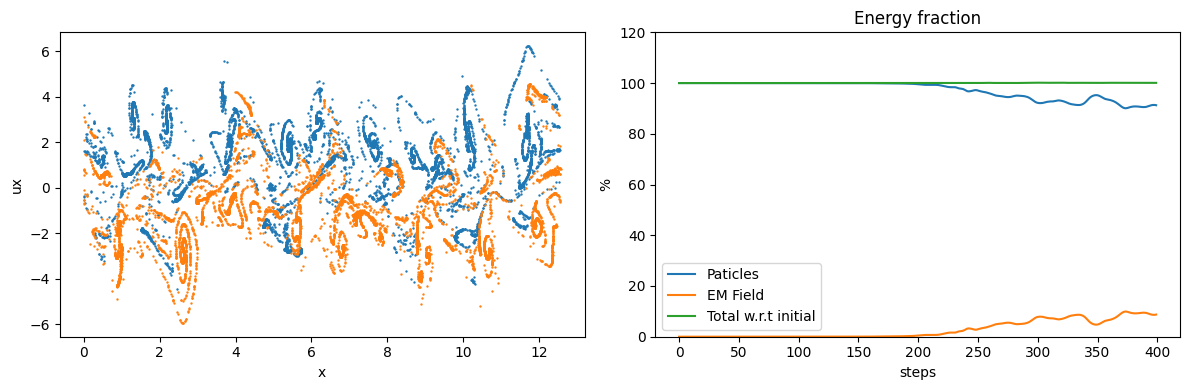

In [ ]:
###########################
# DO NOT MODIFY THIS CELL #
###########################

def test_pic_simulation_two_stream():
    em1d, all_species, EP, EF = run_pic_simulation_two_stream ()

    fig, axs = plt.subplots(1,2, figsize=(12,4))

    axs[0].scatter(all_species["ele1"].x, all_species["ele1"].ux, s=0.5)
    axs[0].scatter(all_species["ele2"].x, all_species["ele2"].ux, s=0.5)
    axs[0].set_xlabel("x")
    axs[0].set_ylabel("ux")

    axs[1].set_title("Energy fraction")
    axs[1].plot(100*(EP)/(EP+EF), label="Paticles")
    axs[1].plot(100*(EF)/(EP+EF), label="EM Field")
    axs[1].plot(100*(EP+EF)/(EP[0]+EF[0]), label="Total w.r.t initial")
    axs[1].set_ylim(0, 120)

    axs[1].set_ylabel("%")
    axs[1].set_xlabel("steps")
    plt.legend()

    plt.tight_layout()

test_pic_simulation_two_stream()

## Exercise 4: PIC simulation of a relativistic filamentation instability

By slightly changing the setup of exercise 3, you can observe [filamentation instability](https://en.wikipedia.org/wiki/Weibel_instability).
Concretely, in `run_pic_simulation_filamentation` change the code that assigns the momenta below `#### ASSIGN INITIAL MOMENTUM`, so that the initial normalized momenta along $y$ are uniformly distributed between $[-2.2, -1.8]$ and $[1.8, 2.2]$. When you are done, run `test_pic_simulation_filamentation` to check your results.

If you have some time, you can:
- try doubling or halving the initial momenta
- try changing just the random spread
- try increasing/decreasing the number of steps to see the initial phase of the instability or its full satuation
- try changing the simulation box size
- try changing the resolution (`num_grid_points`)
- try changing the number of particles per cell (`ppc`)
- ...

In [ ]:
def run_pic_simulation_filamentation ():

    #### SIMULATION BOX
    x0 = 0.0
    x1 = 2*2.0*np.pi
    num_grid_points = 200


    #### CFL
    dx = (x1 - x0)/num_grid_points
    cfl = 0.98
    dt = cfl*dx


    #### DURATION
    steps = 400


    ##### INIT EM FIELD
    em1d = EM1D(num_grid_points, x0, x1)
    xi, xh = em1d.get_coords_without_guard_cells()
    dx = (xi[-1]-xi[0])/(num_grid_points-1)


    #### INIT PLASMA
    n_e    = 1.0
    ppc    = 40

    all_species = {"ele1": species(-1,1),
               "ele2": species(-1,1)}

    def func (x):
        return n_e*(x >= x0)*(x < x1)

    for key in all_species:
        all_species[key].init_plasma(xh, func , ppc, dx)


    #### ASSIGN INITIAL MOMENTUM
    num1 = len(all_species["ele1"].x)
    num2 = len(all_species["ele2"].x)

    ### ADD YOUR CODE HERE ####
    uy1 = np.zeros(num1)
    uy2 = np.zeros(num2)
    all_species["ele1"].uy = uy1
    all_species["ele2"].uy = uy2
    ### ADD YOUR CODE HERE ####

    #######SOLUTION############
    u0    = 2.0
    u0_th = 0.2
    uy1 = np.ones(num1)*u0 + 2*(0.5-np.random.rand(num1))*u0_th
    uy2 = -np.ones(num2)*u0 + 2*(0.5-np.random.rand(num2))*u0_th
    all_species["ele1"].uy = uy1
    all_species["ele2"].uy = uy2
    ###########################

    return do_pic_loop(steps,x0, x1, dx, dt, em1d, all_species)

100%|████████████████████████████████████████| 400/400 [00:03<00:00, 115.32it/s]


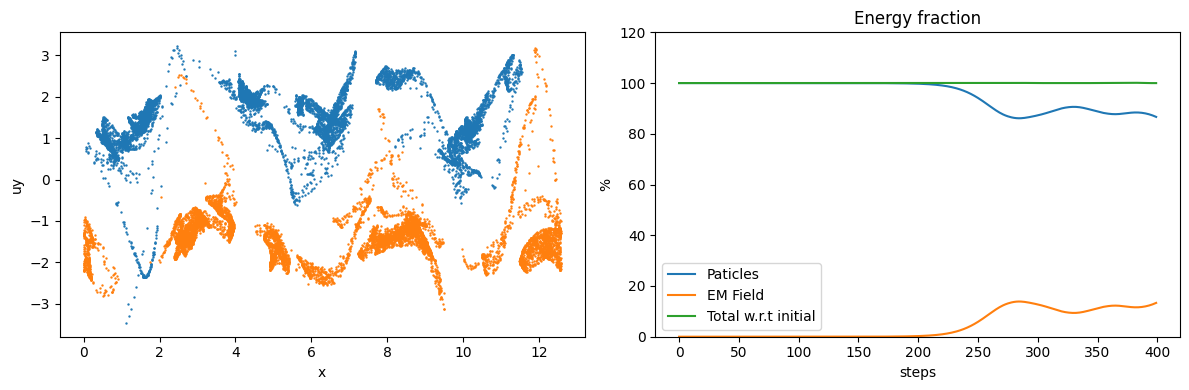

In [ ]:
###########################
# DO NOT MODIFY THIS CELL #
###########################

def test_pic_simulation_filamentation():
    em1d, all_species, EP, EF = run_pic_simulation_filamentation ()

    fig, axs = plt.subplots(1,2, figsize=(12,4))

    axs[0].scatter(all_species["ele1"].x, all_species["ele1"].uy, s=0.5)
    axs[0].scatter(all_species["ele2"].x, all_species["ele2"].uy, s=0.5)
    axs[0].set_xlabel("x")
    axs[0].set_ylabel("uy")

    axs[1].set_title("Energy fraction")
    axs[1].plot(100*(EP)/(EP+EF), label="Paticles")
    axs[1].plot(100*(EF)/(EP+EF), label="EM Field")
    axs[1].plot(100*(EP+EF)/(EP[0]+EF[0]), label="Total w.r.t initial")
    axs[1].set_ylim(0, 120)

    axs[1].set_ylabel("%")
    axs[1].set_xlabel("steps")
    plt.legend()

    plt.tight_layout()

test_pic_simulation_filamentation()

## Exercise 5: laser-plasma interaction

Start by running the two cells below. This time, the simulation case is a laser interacting with an underdense plasma (i.e., a plasma sufficiently tenous to be transparent). In this exercise:

1) try progressively increasing the plasma electron density `n_e` until the laser pulse is no longer transmitted (e.g., try 0.1, 0.5, 1.0, 2.0)
   
2) note that something strange happens with energy conservation: try to fix it by increasing the spatial resolution (and, of course, the number of steps so that the final time is the same). You can slightly reduce the number of particles per cell if the simulation takes too long.

In [ ]:
def run_pic_simulation_laser_plasma ():

    ##### SIMULATION BOX
    x0 = 0.0
    x1 = 80*2.0*np.pi
    num_grid_points = 800
    #num_grid_points = 3200


    #### CFL
    dx = (x1 - x0)/num_grid_points
    cfl = 0.98
    dt = cfl*dx


    #### DURATION
    steps = 600
    #steps = 2400


    ##### INIT EM FIELD
    em1d = EM1D(num_grid_points, x0, x1)
    xi, xh = em1d.get_coords_without_guard_cells()
    dx = (xi[-1]-xi[0])/(num_grid_points-1)


    ##### INIT LASER
    xc = 30.0
    amplitude = 1.0
    em1d.set_transverse_fields(
        lambda x: +np.sin(x)*np.exp(-((x-xc)/8.0)**2)*amplitude,
        None,
        None,
        lambda x: +np.sin(x)*np.exp(-((x-xc)/8.0)**2)*amplitude)

    #### INIT PLASMA
    n_e    = 0.01 # <------- CHANGE THIS (step 1)
    # n_e  = 0.1
    # n_e  = 0.5
    # n_e  = 1.0
    # n_e  = 2.0

    ppc    = 30
    ux0_th = 0.01

    all_species = {"ele": species(-1,1),
               "ion": species(1,1837)}

    xl = 40*2.0*np.pi
    xr = 78*2.0*np.pi
    def func (x):
        return n_e*( (x >= xl)*(x < xr))

    for key in all_species:
        all_species[key].init_plasma(xh, func , ppc, dx)

    num1 = len(all_species["ele"].x)
    all_species["ele"].ux = (0.5-np.random.rand(num1))*ux0_th

    return do_pic_loop(steps,x0, x1, dx, dt, em1d, all_species)


100%|█████████████████████████████████████████| 600/600 [00:07<00:00, 80.99it/s]


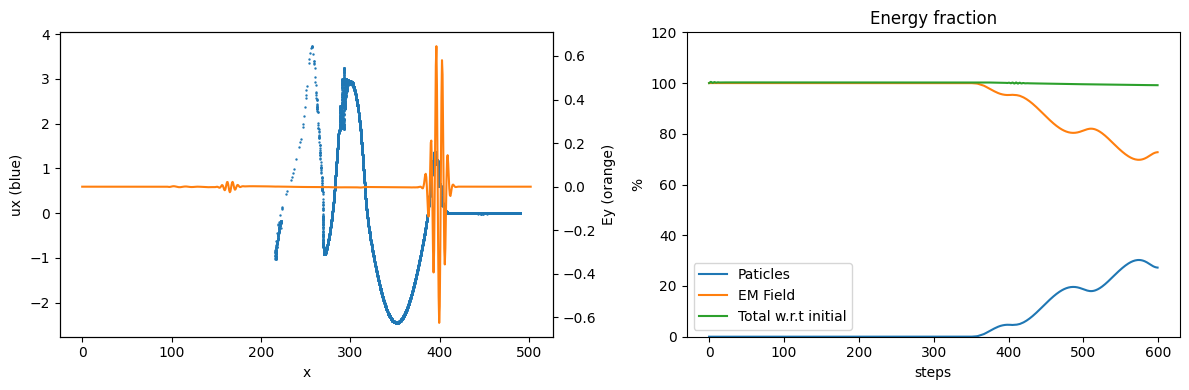

In [ ]:
###########################
# DO NOT MODIFY THIS CELL #
###########################

def test_pic_simulation_laser_plasma():
    em1d, all_species, EP, EF = run_pic_simulation_laser_plasma ()

    fig, axs = plt.subplots(1,2, figsize=(12,4))

    axs[0].scatter(all_species["ele"].x, all_species["ele"].ux, s=0.5)
    ax2 = axs[0].twinx()
    ax2.plot(em1d.get_coords_without_guard_cells()[0], em1d.Ey[em1d.ng:-em1d.ng], c="tab:orange")
    axs[0].set_xlabel("x")
    axs[0].set_ylabel("ux (blue)")
    ax2.set_ylabel("Ey (orange)")

    axs[1].set_title("Energy fraction")
    axs[1].plot(100*(EP)/(EP+EF), label="Paticles")
    axs[1].plot(100*(EF)/(EP+EF), label="EM Field")
    axs[1].plot(100*(EP+EF)/(EP[0]+EF[0]), label="Total w.r.t initial")
    axs[1].set_ylim(0, 120)

    axs[1].set_ylabel("%")
    axs[1].set_xlabel("steps")
    axs[1].legend()

    plt.tight_layout()

test_pic_simulation_laser_plasma()

___